In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 8.0                 # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 8                   # アンサンブルメンバー数
p = 40                  # 観測点の数 (今回は全点観測なので N と同じ)

# [時間設定]
years = 2
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)                       # 観測演算子 H (全点観測)
R_mat = np.eye(N)                       # 観測誤差共分散 R (対角成分1)

# =====================================================================
# 2. Nature Run (真値) と Observation (観測) の生成
# =====================================================================
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 1.001

true_states = []
for s in range(steps_total):
    x = M(x, dt, 1)
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

rng_obs = np.random.default_rng(seed=42) 
noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states.shape)
noise -= np.mean(noise, axis=0)
y_o_data_full = true_states + noise

num_cycles = y_o_data_full.shape[0]

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！



# Adaptive RTPP / RTPS LETKF（全点観測版）

このノートブックでは、固定 \(\alpha\) ではなく、Kotsuki et al. (2017) の observation-space statistics に基づいて、各同化サイクルで \(\alpha\) を診断する adaptive-RTPP / adaptive-RTPS を実装する。

- 観測：全点観測 `obs_indices = np.arange(N)`
- `tmp`：relaxation 前の一時解析摂動 \(X^a_{tmp}\)
- `inf`：relaxation 後の解析摂動 \(X^a_{inf}\)
- `none`：RTPP/RTPS なしの LETKF
- `adaptive_rtpp`：動的 \(\alpha_{RTPP}\)
- `adaptive_rtps`：動的 \(\alpha_{RTPS}\)

基本方針は、通常 LETKF で \(X^a_{tmp}\) を作ったあと、AMB-OMA 統計から診断した \(\alpha\) を時間平滑化して次サイクルに使う、という流れである。


In [2]:

# =====================================================================
# 3. LETKF + adaptive RTPP / adaptive RTPS
# =====================================================================
# 既存コードとできるだけ関数名・変数名をそろえた版。
# dXa_base ではなく、論文式に合わせて dXa_tmp を使う。

import numpy as np
import matplotlib.pyplot as plt


def symmetric_sqrt(A, eig_floor=1.0e-12):
    """
    対称行列 A の対称平方根 A^{1/2} を返す。
    """
    A = np.asarray(A, dtype=float)
    A = 0.5 * (A + A.T)
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
    A = A + eig_floor * np.eye(A.shape[0])

    try:
        eigvals, eigvecs = np.linalg.eigh(A)
        eigvals = np.maximum(eigvals, eig_floor)
        return eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    except np.linalg.LinAlgError:
        u, s, vt = np.linalg.svd(A, full_matrices=False)
        s = np.maximum(s, eig_floor)
        return u @ np.diag(np.sqrt(s)) @ vt



def make_H(obs_indices, N):
    """
    観測点 obs_indices に対応する線形観測演算子 H を作る。
    全点観測なら obs_indices = np.arange(N)。
    """
    obs_indices = np.asarray(obs_indices, dtype=int)
    H = np.zeros((len(obs_indices), N))
    for k, j in enumerate(obs_indices):
        H[k, j] = 1.0
    return H



def gaspari_like_weight(distance, sigma):
    """
    元のノートの R_localization_inv に合わせた簡易ガウス型局所化。
    距離がしきい値より大きい観測は重み0。
    """
    cutoff = np.sqrt(10.0 / 3.0) * sigma * 2.0
    if distance < cutoff:
        return np.exp(-(distance**2) / (2.0 * sigma**2))
    return 0.0



def localization_weights_for_grid(i, obs_indices, sigma, N):
    """
    状態変数 i の解析に使う観測局所化重みを返す。
    戻り値 shape: (p_obs,)
    """
    weights = np.zeros(len(obs_indices))
    for k, j in enumerate(obs_indices):
        d = min(abs(i - j), N - abs(i - j))
        weights[k] = gaspari_like_weight(d, sigma)
    return weights



def _normalized_trace_cov(HX1, HX2, R_diag, m, eps=1.0e-12):
    """
    tr[HX1 (HX2)^T ◦ R^{-1}] / (m-1) を、R が対角の場合に計算する。

    HX1, HX2: shape (p_obs, m)
    R_diag  : shape (p_obs,)
    """
    Rinv_diag = 1.0 / (R_diag + eps)
    return np.sum(HX1 * HX2 * Rinv_diag[:, None]) / (m - 1)



def diagnose_alpha_rtps(stats, eps=1.0e-12):
    """
    adaptive-RTPS の alpha を AMB-OMA statistics から診断する。

    S_diag = tr[d^{a-b}(d^{o-a})^T ◦ R^{-1}]
    S_a    = tr[HXa_tmp(HXa_tmp)^T ◦ R^{-1}] / (m-1)
    S_b    = tr[HXb_relax(HXb_relax)^T ◦ R^{-1}] / (m-1)

    beta = sqrt(S_diag / S_a)
    alpha_RTPS = (beta - 1) / (sqrt(S_b/S_a) - 1)
    """
    y_o = stats["y_o"]
    H = stats["H"]
    R_diag = stats["R_diag"]
    xb_mean = stats["xb_mean"]
    xa_mean = stats["xa_mean"]
    dY_b_relax = stats["dY_b_relax"]
    HXa_tmp = stats["HXa_tmp"]
    m = stats["m"]

    yb_mean = H @ xb_mean
    ya_mean = H @ xa_mean

    do_a = y_o - ya_mean       # OMA = d^{o-a}
    da_b = ya_mean - yb_mean   # AMB = d^{a-b}

    Rinv_diag = 1.0 / (R_diag + eps)
    S_diag = np.sum(da_b * do_a * Rinv_diag)

    S_b = _normalized_trace_cov(dY_b_relax, dY_b_relax, R_diag, m, eps=eps)
    S_a = _normalized_trace_cov(HXa_tmp, HXa_tmp, R_diag, m, eps=eps)

    if (S_diag <= eps) or (S_a <= eps) or (S_b <= eps):
        alpha_raw = 0.0
    else:
        beta = np.sqrt(S_diag / S_a)
        spread_ratio = np.sqrt(S_b / S_a)
        denom = spread_ratio - 1.0
        if abs(denom) <= eps:
            alpha_raw = 0.0
        else:
            alpha_raw = (beta - 1.0) / denom

    alpha_diag = float(np.clip(alpha_raw, 0.0, 1.0))

    info = {
        "S_diag": S_diag,
        "S_b": S_b,
        "S_a": S_a,
        "alpha_raw": alpha_raw,
        "alpha_diag": alpha_diag,
    }
    return alpha_diag, info



def diagnose_alpha_rtpp(stats, eps=1.0e-12):
    """
    adaptive-RTPP の alpha を AMB-OMA statistics から診断する。

    RTPP:
        Xa_inf = alpha Xb_relax + (1-alpha) Xa_tmp

    AMB-OMA statistics に代入すると、
        lambda1 alpha^2 + lambda2 alpha + lambda3 = 0
    となる。
    """
    y_o = stats["y_o"]
    H = stats["H"]
    R_diag = stats["R_diag"]
    xb_mean = stats["xb_mean"]
    xa_mean = stats["xa_mean"]
    dY_b_relax = stats["dY_b_relax"]
    HXa_tmp = stats["HXa_tmp"]
    m = stats["m"]

    yb_mean = H @ xb_mean
    ya_mean = H @ xa_mean

    do_a = y_o - ya_mean       # OMA = d^{o-a}
    da_b = ya_mean - yb_mean   # AMB = d^{a-b}

    Rinv_diag = 1.0 / (R_diag + eps)

    # A1, A2, A3, A4 correspond to Appendix A in Kotsuki et al. (2017)
    A1 = _normalized_trace_cov(dY_b_relax, dY_b_relax, R_diag, m, eps=eps)
    A2 = _normalized_trace_cov(HXa_tmp, dY_b_relax, R_diag, m, eps=eps)
    A3 = _normalized_trace_cov(HXa_tmp, HXa_tmp, R_diag, m, eps=eps)
    A4 = np.sum(da_b * do_a * Rinv_diag)

    lambda1 = A1 - 2.0 * A2 + A3
    lambda2 = 2.0 * A2 - 2.0 * A3
    lambda3 = A3 - A4

    # lambda1 alpha^2 + lambda2 alpha + lambda3 = 0 を解く。
    # 論文では正の解を採用し、その後 [0, 1] に制限する。
    if abs(lambda1) <= eps:
        if abs(lambda2) <= eps:
            alpha_raw = 0.0
            discriminant = np.nan
        else:
            alpha_raw = -lambda3 / lambda2
            discriminant = np.nan
    else:
        discriminant = lambda2**2 - 4.0 * lambda1 * lambda3
        if discriminant < 0.0:
            alpha_raw = 0.0
        else:
            sqrt_disc = np.sqrt(discriminant)
            root1 = (-lambda2 + sqrt_disc) / (2.0 * lambda1)
            root2 = (-lambda2 - sqrt_disc) / (2.0 * lambda1)
            roots = np.array([root1, root2], dtype=float)

            # まず [0, 1] 内の解を優先。
            valid = roots[(roots >= 0.0) & (roots <= 1.0)]
            if len(valid) > 0:
                alpha_raw = float(valid[0])
            else:
                # なければ正の解を選び、最後に clip する。
                positive = roots[roots >= 0.0]
                alpha_raw = float(positive[0]) if len(positive) > 0 else 0.0

    alpha_diag = float(np.clip(alpha_raw, 0.0, 1.0))

    info = {
        "A1": A1,
        "A2": A2,
        "A3": A3,
        "A4": A4,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "lambda3": lambda3,
        "discriminant": discriminant,
        "alpha_raw": alpha_raw,
        "alpha_diag": alpha_diag,
    }
    return alpha_diag, info



def letkf_analysis(
    X_b,
    y_o,
    H,
    R,
    obs_indices,
    sigma,
    inflation=1.0,
    method="none",
    alpha=0.0,
    eps=1.0e-12,
    return_tmp=False,
):
    """
    1同化サイクル分の LETKF 解析を行う。

    method:
        "none" : 通常LETKF
        "rtpp" : RTPP LETKF。adaptive-RTPP でも、ここにはその時刻で使う alpha を渡す。
        "rtps" : RTPS LETKF。adaptive-RTPS でも、ここにはその時刻で使う alpha を渡す。

    tmp:
        dXa_tmp = relaxation 前の一時解析摂動。

    inf:
        dXa = relaxation 後の解析摂動。
    """
    N, m = X_b.shape
    obs_indices = np.asarray(obs_indices, dtype=int)

    # 1. background mean and perturbation
    xb_mean = np.mean(X_b, axis=1)
    dX_b = X_b - xb_mean[:, None]

    # 2. observation ensemble
    Y_b_ens = H @ X_b
    yb_mean = np.mean(Y_b_ens, axis=1)
    dY_b = Y_b_ens - yb_mean[:, None]

    # relaxation で prior 側に戻すときの背景摂動。
    # inflation=1 なら dX_b_relax = dX_b。
    dX_b_relax = np.sqrt(inflation) * dX_b
    dY_b_relax = np.sqrt(inflation) * dY_b

    # 3. innovation
    innovation = y_o - yb_mean

    # 4. output arrays
    X_a = np.zeros_like(X_b)
    xa_mean = np.zeros(N)
    dXa = np.zeros_like(X_b)
    dXa_tmp = np.zeros_like(X_b)

    R_diag = np.diag(R)

    for i in range(N):
        # 5. local R^{-1}
        loc_weights = localization_weights_for_grid(i, obs_indices, sigma, N)
        Rloc_inv_diag = loc_weights / R_diag

        # 6. P_a_tilde
        # P_a_tilde = [ (m-1)/Delta I + dY_b^T Rloc^{-1} dY_b ]^{-1}
        Rinv_dY = Rloc_inv_diag[:, None] * dY_b
        A = ((m - 1) / inflation) * np.eye(m) + dY_b.T @ Rinv_dY
        A = 0.5 * (A + A.T)
        A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
        P_a_tilde = np.linalg.pinv(A, rcond=1.0e-12)
        P_a_tilde = 0.5 * (P_a_tilde + P_a_tilde.T)

        # 7. mean weight
        # w = P_a_tilde dY_b^T Rloc^{-1} innovation
        Rinv_innov = Rloc_inv_diag * innovation
        w = P_a_tilde @ dY_b.T @ Rinv_innov

        # 8. analysis mean
        # xa_mean_i = xb_mean_i + dX_b_i w
        xa_mean[i] = xb_mean[i] + dX_b[i, :] @ w

        # 9. transform matrix
        # W = [ (m-1) P_a_tilde ]^{1/2}
        W = symmetric_sqrt((m - 1) * P_a_tilde)

        # 10. temporary analysis perturbation
        # dXa_tmp_i = dX_b_i W
        dXa_tmp_i = dX_b[i, :] @ W
        dXa_tmp_i = dXa_tmp_i - np.mean(dXa_tmp_i)
        dXa_tmp[i, :] = dXa_tmp_i

        # 11. relaxation method
        if method == "none":
            dXa_i = dXa_tmp_i

        elif method == "rtpp":
            # dXa_inf = (1-alpha)dXa_tmp + alpha sqrt(Delta)dX_b
            dXa_i = (1.0 - alpha) * dXa_tmp_i + alpha * dX_b_relax[i, :]

        elif method == "rtps":
            # sigma_b_i = std(sqrt(Delta)dX_b_i), sigma_a_i = std(dXa_tmp_i)
            sigma_b_i = np.std(dX_b_relax[i, :], ddof=1)
            sigma_a_i = np.std(dXa_tmp_i, ddof=1)

            # r_i = 1-alpha + alpha sigma_b_i / sigma_a_i
            rtps_factor_i = 1.0 - alpha + alpha * sigma_b_i / (sigma_a_i + eps)
            dXa_i = rtps_factor_i * dXa_tmp_i

        else:
            raise ValueError("method must be 'none', 'rtpp', or 'rtps'.")

        # 12. perturbation mean should be zero
        dXa_i = dXa_i - np.mean(dXa_i)

        dXa[i, :] = dXa_i
        X_a[i, :] = xa_mean[i] + dXa_i

    if not return_tmp:
        return X_a, xa_mean, dXa

    HXa_tmp = H @ dXa_tmp

    stats = {
        "X_b": X_b,
        "xb_mean": xb_mean,
        "dX_b": dX_b,
        "dX_b_relax": dX_b_relax,
        "dY_b": dY_b,
        "dY_b_relax": dY_b_relax,
        "y_o": y_o,
        "yb_mean": yb_mean,
        "innovation": innovation,
        "X_a": X_a,
        "xa_mean": xa_mean,
        "dXa": dXa,
        "dXa_tmp": dXa_tmp,
        "HXa_tmp": HXa_tmp,
        "H": H,
        "R": R,
        "R_diag": R_diag,
        "obs_indices": obs_indices,
        "m": m,
    }

    return X_a, xa_mean, dXa, stats



def run_letkf_experiment(
    y_o_data,
    true_states,
    obs_indices=None,
    sigma=3.0,
    inflation=1.0,
    method="none",
    alpha=0.0,
    seed=42,
):
    """
    固定 alpha の LETKF 実験。
    method='none', 'rtpp', 'rtps' を切り替える。
    """
    if obs_indices is None:
        obs_indices = np.arange(N)

    obs_indices = np.asarray(obs_indices, dtype=int)
    H = make_H(obs_indices, N)
    R = np.eye(len(obs_indices))

    y_obs = y_o_data[:, obs_indices]

    num_cycles_local = y_obs.shape[0]
    record_rmse = np.zeros(num_cycles_local)
    record_spread = np.zeros(num_cycles_local)

    rng_enkf = np.random.default_rng(seed=seed)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)

    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N - 1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)

    for t in range(num_cycles_local):
        X_b = M(X_a, dt, sampling_interval)

        X_a, xa_mean, dXa = letkf_analysis(
            X_b=X_b,
            y_o=y_obs[t],
            H=H,
            R=R,
            obs_indices=obs_indices,
            sigma=sigma,
            inflation=inflation,
            method=method,
            alpha=alpha,
        )

        record_rmse[t] = np.sqrt(np.mean((xa_mean - true_states[t]) ** 2))
        record_spread[t] = np.mean(np.std(X_a, axis=1, ddof=1))

    return record_rmse, record_spread



def run_adaptive_letkf_experiment(
    y_o_data,
    true_states,
    obs_indices=None,
    sigma=3.0,
    inflation=1.0,
    adaptive_method="rtpp",
    alpha_init=0.5,
    tau=0.03,
    seed=42,
    eps=1.0e-12,
):
    """
    adaptive-RTPP / adaptive-RTPS LETKF 実験。

    adaptive_method:
        "rtpp" or "rtps"

    論文と同様に、時刻 t の解析では前時刻の smoothed alpha を使い、
    解析後に AMB-OMA statistics から alpha_diag(t) を診断して、
    alpha_smooth(t) = tau alpha_diag(t) + (1-tau) alpha_smooth(t-1)
    で更新する。
    """
    if adaptive_method not in ["rtpp", "rtps"]:
        raise ValueError("adaptive_method must be 'rtpp' or 'rtps'.")

    if obs_indices is None:
        obs_indices = np.arange(N)

    obs_indices = np.asarray(obs_indices, dtype=int)
    H = make_H(obs_indices, N)
    R = np.eye(len(obs_indices))

    y_obs = y_o_data[:, obs_indices]

    num_cycles_local = y_obs.shape[0]
    record_rmse = np.zeros(num_cycles_local)
    record_spread = np.zeros(num_cycles_local)
    record_alpha_use = np.zeros(num_cycles_local)
    record_alpha_diag = np.zeros(num_cycles_local)
    record_alpha_smooth = np.zeros(num_cycles_local)
    record_alpha_raw = np.zeros(num_cycles_local)

    alpha_info_list = []

    rng_enkf = np.random.default_rng(seed=seed)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)

    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N - 1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)

    alpha_smooth = float(alpha_init)

    for t in range(num_cycles_local):
        X_b = M(X_a, dt, sampling_interval)

        alpha_use = alpha_smooth
        record_alpha_use[t] = alpha_use

        # 現時刻では前時刻から持ち越した smoothed alpha を使う。
        X_a, xa_mean, dXa, stats = letkf_analysis(
            X_b=X_b,
            y_o=y_obs[t],
            H=H,
            R=R,
            obs_indices=obs_indices,
            sigma=sigma,
            inflation=inflation,
            method=adaptive_method,
            alpha=alpha_use,
            return_tmp=True,
        )

        # relaxation 前の tmp 解析摂動と AMB-OMA statistics から alpha を診断する。
        if adaptive_method == "rtpp":
            alpha_diag, info = diagnose_alpha_rtpp(stats, eps=eps)
        else:
            alpha_diag, info = diagnose_alpha_rtps(stats, eps=eps)

        alpha_raw = info.get("alpha_raw", alpha_diag)
        alpha_smooth = tau * alpha_diag + (1.0 - tau) * alpha_smooth
        alpha_smooth = float(np.clip(alpha_smooth, 0.0, 1.0))

        record_alpha_diag[t] = alpha_diag
        record_alpha_smooth[t] = alpha_smooth
        record_alpha_raw[t] = alpha_raw
        alpha_info_list.append(info)

        record_rmse[t] = np.sqrt(np.mean((xa_mean - true_states[t]) ** 2))
        record_spread[t] = np.mean(np.std(X_a, axis=1, ddof=1))

    return {
        "rmse": record_rmse,
        "spread": record_spread,
        "alpha_use": record_alpha_use,
        "alpha_diag": record_alpha_diag,
        "alpha_smooth": record_alpha_smooth,
        "alpha_raw": record_alpha_raw,
        "alpha_info": alpha_info_list,
    }



## 実装上の対応

- `dXa_tmp` が論文の \(X^a_{tmp}\) に対応する。
- `dXa` が relaxation 後の \(X^a_{inf}\) に対応する。
- `alpha_diag` は AMB-OMA statistics からその時刻に診断した値。
- `alpha_smooth` は時間平滑化後の値。
- 時刻 `t` の解析では、前時刻から持ち越した `alpha_smooth` を `alpha_use` として使い、解析後に `alpha_diag` を計算して `alpha_smooth` を更新する。

最初は `inflation = 1.0` として、乗算的インフレーションを併用せず、adaptive-RTPP / adaptive-RTPS の効果だけを見る設定にしている。


In [3]:

# =====================================================================
# 4. 全点観測で adaptive-RTPP / adaptive-RTPS を実行
# =====================================================================

num_eval_cycles = num_cycles       # 全期間で回すなら num_cycles に変更
spinup = 0

sigma = 4.0
inflation = 1.0             # まずは論文式に忠実に、乗算的 inflation なし。
obs_indices = np.arange(N)  # 全点観測

alpha_init = 0.5
alpha_tau = 0.03
seed = 42

results_adaptive = {}

print("Running baseline LETKF / none ...")
rmse_none, spread_none = run_letkf_experiment(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices,
    sigma=sigma,
    inflation=inflation,
    method="none",
    alpha=0.0,
    seed=seed,
)
results_adaptive["none"] = {
    "rmse": rmse_none,
    "spread": spread_none,
}
print(f"none: mean RMSE = {np.mean(rmse_none[spinup:]):.4f}, mean spread = {np.mean(spread_none[spinup:]):.4f}")

print("Running adaptive RTPP ...")
results_adaptive["adaptive_rtpp"] = run_adaptive_letkf_experiment(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices,
    sigma=sigma,
    inflation=inflation,
    adaptive_method="rtpp",
    alpha_init=alpha_init,
    tau=alpha_tau,
    seed=seed,
)
print(
    f"adaptive_rtpp: mean RMSE = {np.mean(results_adaptive['adaptive_rtpp']['rmse'][spinup:]):.4f}, "
    f"mean spread = {np.mean(results_adaptive['adaptive_rtpp']['spread'][spinup:]):.4f}, "
    f"mean alpha = {np.mean(results_adaptive['adaptive_rtpp']['alpha_smooth'][spinup:]):.4f}"
)

print("Running adaptive RTPS ...")
results_adaptive["adaptive_rtps"] = run_adaptive_letkf_experiment(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices,
    sigma=sigma,
    inflation=inflation,
    adaptive_method="rtps",
    alpha_init=alpha_init,
    tau=alpha_tau,
    seed=seed,
)
print(
    f"adaptive_rtps: mean RMSE = {np.mean(results_adaptive['adaptive_rtps']['rmse'][spinup:]):.4f}, "
    f"mean spread = {np.mean(results_adaptive['adaptive_rtps']['spread'][spinup:]):.4f}, "
    f"mean alpha = {np.mean(results_adaptive['adaptive_rtps']['alpha_smooth'][spinup:]):.4f}"
)

print("Done.")

# summary table
try:
    import pandas as pd
    summary_rows = []
    for name, res in results_adaptive.items():
        row = {
            "method": name,
            "mean_rmse": np.mean(res["rmse"][spinup:]),
            "mean_spread": np.mean(res["spread"][spinup:]),
            "spread_rmse_ratio": np.mean(res["spread"][spinup:]) / (np.mean(res["rmse"][spinup:]) + 1.0e-12),
        }
        if "alpha_smooth" in res:
            row["mean_alpha_smooth"] = np.mean(res["alpha_smooth"][spinup:])
            row["mean_alpha_diag"] = np.mean(res["alpha_diag"][spinup:])
        summary_rows.append(row)
    summary_adaptive_df = pd.DataFrame(summary_rows)
    display(summary_adaptive_df)
except Exception:
    pass


Running baseline LETKF / none ...
none: mean RMSE = 3.1627, mean spread = 0.1676
Running adaptive RTPP ...
adaptive_rtpp: mean RMSE = 0.2423, mean spread = 0.2044, mean alpha = 0.3122
Running adaptive RTPS ...
adaptive_rtps: mean RMSE = 0.2239, mean spread = 0.2190, mean alpha = 0.2875
Done.


,method,mean_rmse,mean_spread,spread_rmse_ratio,mean_alpha_smooth,mean_alpha_diag
0,none,3.162744,0.167621,0.052999,NaN,NaN
1,adaptive_rtpp,0.242299,0.204434,0.843724,0.312211,0.309043
2,adaptive_rtps,0.223931,0.219040,0.978160,0.287550,0.283613


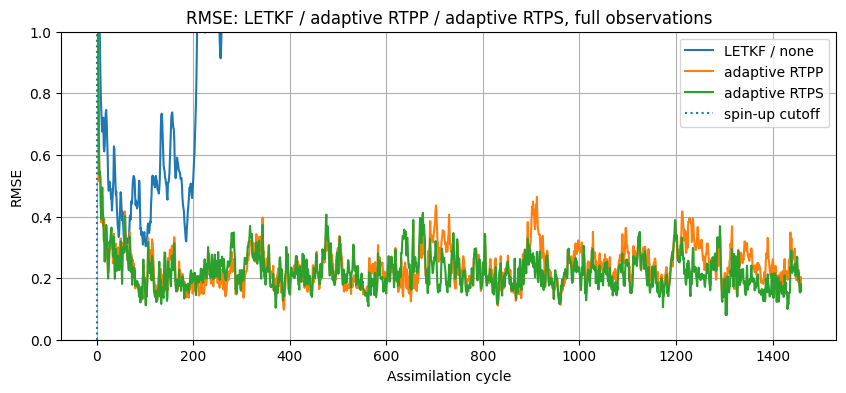

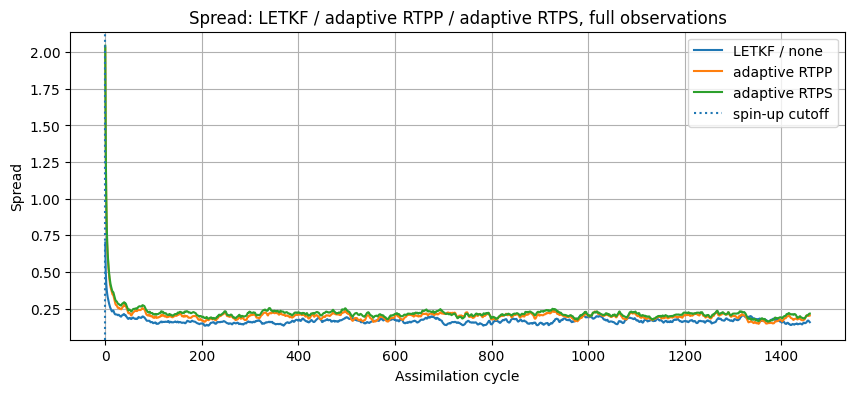

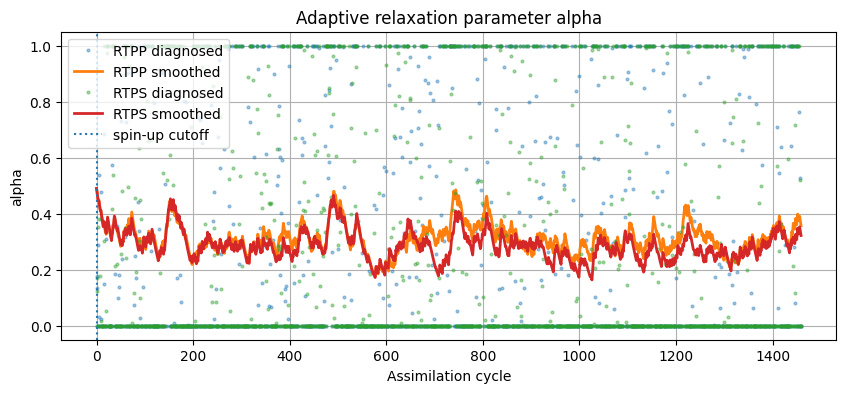

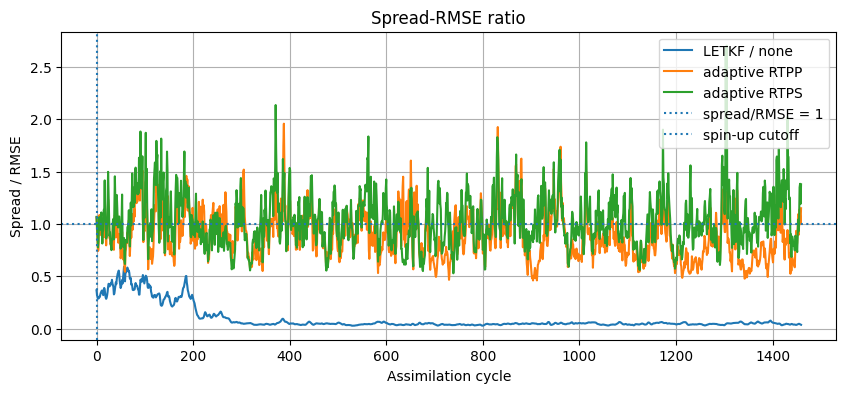

Mean RMSE of RTPP: 0.24229931877536962
Mean RMSE of RTPS: 0.2239311815603764
Mean RMSE of LETKF: 3.1627440006659833
Mean alpha_smooth of RTPP: 0.31221133145991403
Mean alpha diag of RTPP: 0.30904318614515197
Mean alpha_smooth of RTPS: 0.28754982949727337
Mean alpha diag of RTPS: 0.28361301512480824


In [4]:

# =====================================================================
# 5. RMSE / Spread / alpha の可視化
# =====================================================================

plt.figure(figsize=(10, 4))
plt.plot(results_adaptive["none"]["rmse"], label="LETKF / none")
plt.plot(results_adaptive["adaptive_rtpp"]["rmse"], label="adaptive RTPP")
plt.plot(results_adaptive["adaptive_rtps"]["rmse"], label="adaptive RTPS")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("RMSE")
plt.ylim(0, 1.0)
plt.title("RMSE: LETKF / adaptive RTPP / adaptive RTPS, full observations")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(results_adaptive["none"]["spread"], label="LETKF / none")
plt.plot(results_adaptive["adaptive_rtpp"]["spread"], label="adaptive RTPP")
plt.plot(results_adaptive["adaptive_rtps"]["spread"], label="adaptive RTPS")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("Spread")
plt.title("Spread: LETKF / adaptive RTPP / adaptive RTPS, full observations")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(results_adaptive["adaptive_rtpp"]["alpha_diag"], marker="o", markersize=2, linestyle="None", alpha=0.4, label="RTPP diagnosed")
plt.plot(results_adaptive["adaptive_rtpp"]["alpha_smooth"], linewidth=2, label="RTPP smoothed")
plt.plot(results_adaptive["adaptive_rtps"]["alpha_diag"], marker="o", markersize=2, linestyle="None", alpha=0.4, label="RTPS diagnosed")
plt.plot(results_adaptive["adaptive_rtps"]["alpha_smooth"], linewidth=2, label="RTPS smoothed")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("alpha")
plt.title("Adaptive relaxation parameter alpha")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for name, label in [
    ("none", "LETKF / none"),
    ("adaptive_rtpp", "adaptive RTPP"),
    ("adaptive_rtps", "adaptive RTPS"),
]:
    ratio = results_adaptive[name]["spread"] / (results_adaptive[name]["rmse"] + 1.0e-12)
    plt.plot(ratio, label=label)
plt.axhline(1.0, linestyle=":", label="spread/RMSE = 1")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("Spread / RMSE")
plt.title("Spread-RMSE ratio")
plt.grid(True)
plt.legend()
plt.show()

print(f"Mean RMSE of RTPP: {np.mean(results_adaptive['adaptive_rtpp']['rmse'][spinup:])}")
print(f"Mean RMSE of RTPS: {np.mean(results_adaptive['adaptive_rtps']['rmse'][spinup:])}")
print(f"Mean RMSE of LETKF: {np.mean(results_adaptive['none']['rmse'][spinup:])}")

print(f"Mean alpha_smooth of RTPP: {np.mean(results_adaptive['adaptive_rtpp']['alpha_smooth'][spinup:])}")
print(f"Mean alpha diag of RTPP: {np.mean(results_adaptive['adaptive_rtpp']['alpha_diag'][spinup:])}")
print(f"Mean alpha_smooth of RTPS: {np.mean(results_adaptive['adaptive_rtps']['alpha_smooth'][spinup:])}")
print(f"Mean alpha diag of RTPS: {np.mean(results_adaptive['adaptive_rtps']['alpha_diag'][spinup:])}")

In [5]:
# =====================================================================
# Land / Ocean experiment with global adaptive alpha
# Land = 前半20点, Ocean = 後半20点
# 観測は Land 側のみ、alpha は Global で1つ診断して全領域に適用
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Land / Ocean の定義
# ------------------------------------------------------------
land_indices = np.arange(N // 2)
ocean_indices = np.arange(N // 2, N)
global_indices = np.arange(N)

# 今回の Land/Ocean 実験では Land 側だけ観測する
obs_indices_land_ocean = land_indices.copy()

print("Land indices :", land_indices)
print("Ocean indices:", ocean_indices)
print("Observation indices:", obs_indices_land_ocean)

# ------------------------------------------------------------
# 2. RMSE / Spread を領域別に計算する関数
# ------------------------------------------------------------
def compute_regional_rmse(x_mean, x_true, region_indices):
    return np.sqrt(np.mean((x_mean[region_indices] - x_true[region_indices]) ** 2))


def compute_regional_spread(X_a, region_indices):
    return np.mean(np.std(X_a[region_indices, :], axis=1, ddof=1))


# ------------------------------------------------------------
# 3. 固定 alpha / none 用の regional 実験関数
# ------------------------------------------------------------
def run_letkf_experiment_regional(
    y_o_data,
    true_states,
    obs_indices=None,
    sigma=4.0,
    inflation=1.0,
    method="none",
    alpha=0.0,
    seed=42,
):
    """
    通常 LETKF / 固定 alpha の RTPP / RTPS 実験。
    Global, Land, Ocean の RMSE / Spread を記録する。
    """
    if obs_indices is None:
        obs_indices = np.arange(N)

    obs_indices = np.asarray(obs_indices, dtype=int)
    H = make_H(obs_indices, N)
    R = np.eye(len(obs_indices))

    y_obs = y_o_data[:, obs_indices]
    num_cycles_local = y_obs.shape[0]

    record_rmse_global = np.zeros(num_cycles_local)
    record_rmse_land = np.zeros(num_cycles_local)
    record_rmse_ocean = np.zeros(num_cycles_local)

    record_spread_global = np.zeros(num_cycles_local)
    record_spread_land = np.zeros(num_cycles_local)
    record_spread_ocean = np.zeros(num_cycles_local)

    rng_enkf = np.random.default_rng(seed=seed)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)

    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N - 1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)

    for t in range(num_cycles_local):
        X_b = M(X_a, dt, sampling_interval)

        X_a, xa_mean, dXa = letkf_analysis(
            X_b=X_b,
            y_o=y_obs[t],
            H=H,
            R=R,
            obs_indices=obs_indices,
            sigma=sigma,
            inflation=inflation,
            method=method,
            alpha=alpha,
        )

        x_true = true_states[t]

        record_rmse_global[t] = compute_regional_rmse(xa_mean, x_true, global_indices)
        record_rmse_land[t] = compute_regional_rmse(xa_mean, x_true, land_indices)
        record_rmse_ocean[t] = compute_regional_rmse(xa_mean, x_true, ocean_indices)

        record_spread_global[t] = compute_regional_spread(X_a, global_indices)
        record_spread_land[t] = compute_regional_spread(X_a, land_indices)
        record_spread_ocean[t] = compute_regional_spread(X_a, ocean_indices)

    return {
        "rmse": record_rmse_global,
        "rmse_global": record_rmse_global,
        "rmse_land": record_rmse_land,
        "rmse_ocean": record_rmse_ocean,
        "spread": record_spread_global,
        "spread_global": record_spread_global,
        "spread_land": record_spread_land,
        "spread_ocean": record_spread_ocean,
    }


# ------------------------------------------------------------
# 4. adaptive alpha 用の regional 実験関数
# ------------------------------------------------------------
def run_adaptive_letkf_experiment_regional(
    y_o_data,
    true_states,
    obs_indices=None,
    sigma=4.0,
    inflation=1.0,
    adaptive_method="rtpp",
    alpha_init=0.5,
    tau=0.03,
    seed=42,
    eps=1.0e-12,
):
    """
    adaptive-RTPP / adaptive-RTPS LETKF 実験。
    alpha は Global で1つだけ診断し、全格子点に同じ alpha を適用する。
    Global, Land, Ocean の RMSE / Spread を記録する。
    """
    if adaptive_method not in ["rtpp", "rtps"]:
        raise ValueError("adaptive_method must be 'rtpp' or 'rtps'.")

    if obs_indices is None:
        obs_indices = np.arange(N)

    obs_indices = np.asarray(obs_indices, dtype=int)
    H = make_H(obs_indices, N)
    R = np.eye(len(obs_indices))

    y_obs = y_o_data[:, obs_indices]
    num_cycles_local = y_obs.shape[0]

    record_rmse_global = np.zeros(num_cycles_local)
    record_rmse_land = np.zeros(num_cycles_local)
    record_rmse_ocean = np.zeros(num_cycles_local)

    record_spread_global = np.zeros(num_cycles_local)
    record_spread_land = np.zeros(num_cycles_local)
    record_spread_ocean = np.zeros(num_cycles_local)

    record_alpha_use = np.zeros(num_cycles_local)
    record_alpha_diag = np.zeros(num_cycles_local)
    record_alpha_smooth = np.zeros(num_cycles_local)
    record_alpha_raw = np.zeros(num_cycles_local)

    alpha_info_list = []

    rng_enkf = np.random.default_rng(seed=seed)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)

    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N - 1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)

    alpha_smooth = float(alpha_init)

    for t in range(num_cycles_local):
        X_b = M(X_a, dt, sampling_interval)

        alpha_use = alpha_smooth
        record_alpha_use[t] = alpha_use

        X_a, xa_mean, dXa, stats = letkf_analysis(
            X_b=X_b,
            y_o=y_obs[t],
            H=H,
            R=R,
            obs_indices=obs_indices,
            sigma=sigma,
            inflation=inflation,
            method=adaptive_method,
            alpha=alpha_use,
            return_tmp=True,
        )

        if adaptive_method == "rtpp":
            alpha_diag, info = diagnose_alpha_rtpp(stats, eps=eps)
        else:
            alpha_diag, info = diagnose_alpha_rtps(stats, eps=eps)

        alpha_raw = info.get("alpha_raw", alpha_diag)

        alpha_smooth = tau * alpha_diag + (1.0 - tau) * alpha_smooth
        alpha_smooth = float(np.clip(alpha_smooth, 0.0, 1.0))

        record_alpha_diag[t] = alpha_diag
        record_alpha_smooth[t] = alpha_smooth
        record_alpha_raw[t] = alpha_raw
        alpha_info_list.append(info)

        x_true = true_states[t]

        record_rmse_global[t] = compute_regional_rmse(xa_mean, x_true, global_indices)
        record_rmse_land[t] = compute_regional_rmse(xa_mean, x_true, land_indices)
        record_rmse_ocean[t] = compute_regional_rmse(xa_mean, x_true, ocean_indices)

        record_spread_global[t] = compute_regional_spread(X_a, global_indices)
        record_spread_land[t] = compute_regional_spread(X_a, land_indices)
        record_spread_ocean[t] = compute_regional_spread(X_a, ocean_indices)

    return {
        "rmse": record_rmse_global,
        "rmse_global": record_rmse_global,
        "rmse_land": record_rmse_land,
        "rmse_ocean": record_rmse_ocean,
        "spread": record_spread_global,
        "spread_global": record_spread_global,
        "spread_land": record_spread_land,
        "spread_ocean": record_spread_ocean,
        "alpha_use": record_alpha_use,
        "alpha_diag": record_alpha_diag,
        "alpha_smooth": record_alpha_smooth,
        "alpha_raw": record_alpha_raw,
        "alpha_info": alpha_info_list,
    }


# ------------------------------------------------------------
# 5. Land / Ocean 実験を実行
# ------------------------------------------------------------
results_adaptive_land_ocean = {}

print("Running baseline LETKF / none, Land observations only ...")
results_adaptive_land_ocean["none"] = run_letkf_experiment_regional(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices_land_ocean,
    sigma=sigma,
    inflation=inflation,
    method="none",
    alpha=0.0,
    seed=seed,
)

print(
    "none:",
    f"Global RMSE = {np.mean(results_adaptive_land_ocean['none']['rmse_global'][spinup:]):.4f},",
    f"Land RMSE = {np.mean(results_adaptive_land_ocean['none']['rmse_land'][spinup:]):.4f},",
    f"Ocean RMSE = {np.mean(results_adaptive_land_ocean['none']['rmse_ocean'][spinup:]):.4f}"
)

print("Running adaptive RTPP, Land observations only ...")
results_adaptive_land_ocean["adaptive_rtpp"] = run_adaptive_letkf_experiment_regional(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices_land_ocean,
    sigma=sigma,
    inflation=inflation,
    adaptive_method="rtpp",
    alpha_init=alpha_init,
    tau=alpha_tau,
    seed=seed,
)

print(
    "adaptive_rtpp:",
    f"Global RMSE = {np.mean(results_adaptive_land_ocean['adaptive_rtpp']['rmse_global'][spinup:]):.4f},",
    f"Land RMSE = {np.mean(results_adaptive_land_ocean['adaptive_rtpp']['rmse_land'][spinup:]):.4f},",
    f"Ocean RMSE = {np.mean(results_adaptive_land_ocean['adaptive_rtpp']['rmse_ocean'][spinup:]):.4f},",
    f"mean alpha = {np.mean(results_adaptive_land_ocean['adaptive_rtpp']['alpha_smooth'][spinup:]):.4f}"
)

print("Running adaptive RTPS, Land observations only ...")
results_adaptive_land_ocean["adaptive_rtps"] = run_adaptive_letkf_experiment_regional(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices_land_ocean,
    sigma=sigma,
    inflation=inflation,
    adaptive_method="rtps",
    alpha_init=alpha_init,
    tau=alpha_tau,
    seed=seed,
)

print(
    "adaptive_rtps:",
    f"Global RMSE = {np.mean(results_adaptive_land_ocean['adaptive_rtps']['rmse_global'][spinup:]):.4f},",
    f"Land RMSE = {np.mean(results_adaptive_land_ocean['adaptive_rtps']['rmse_land'][spinup:]):.4f},",
    f"Ocean RMSE = {np.mean(results_adaptive_land_ocean['adaptive_rtps']['rmse_ocean'][spinup:]):.4f},",
    f"mean alpha = {np.mean(results_adaptive_land_ocean['adaptive_rtps']['alpha_smooth'][spinup:]):.4f}"
)

print("Done.")



Land indices : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Ocean indices: [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Observation indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Running baseline LETKF / none, Land observations only ...
none: Global RMSE = 2.4947, Land RMSE = 0.6565, Ocean RMSE = 3.4487
Running adaptive RTPP, Land observations only ...
adaptive_rtpp: Global RMSE = 2.2781, Land RMSE = 0.4290, Ocean RMSE = 3.1877, mean alpha = 0.2917
Running adaptive RTPS, Land observations only ...
adaptive_rtps: Global RMSE = 2.2463, Land RMSE = 0.3833, Ocean RMSE = 3.1498, mean alpha = 0.2701
Done.


,method,mean_rmse_global,mean_rmse_land,mean_rmse_ocean,mean_spread_global,mean_spread_land,mean_spread_ocean,mean_alpha_smooth,mean_alpha_diag
0,none,2.494654,0.656539,3.448712,1.143984,0.237776,2.050191,NaN,NaN
1,adaptive_rtpp,2.278106,0.429004,3.187748,1.226865,0.302587,2.151142,0.291656,0.290753
2,adaptive_rtps,2.246334,0.383346,3.149806,1.250150,0.311217,2.189083,0.270061,0.264218


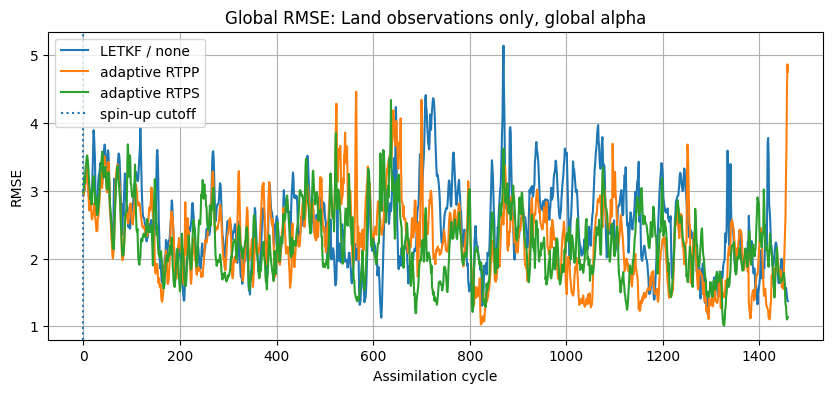

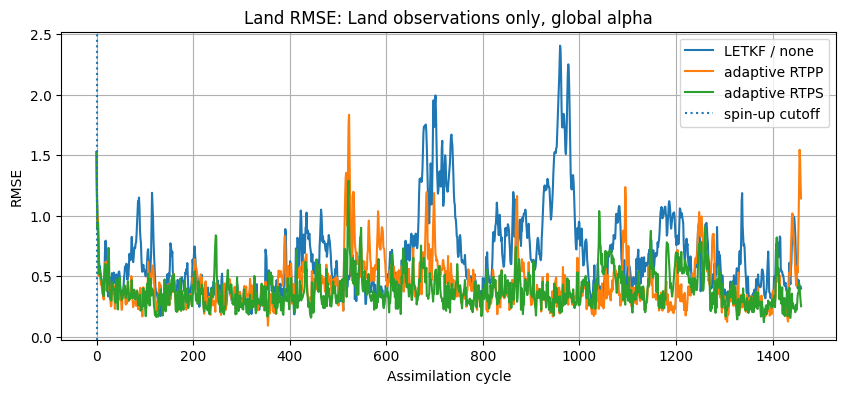

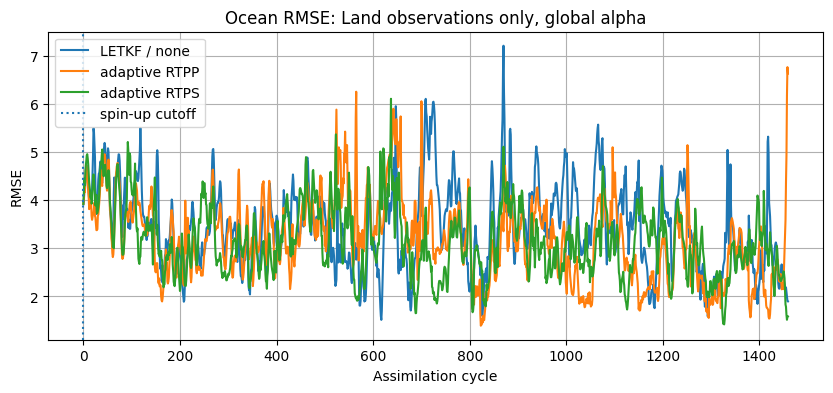

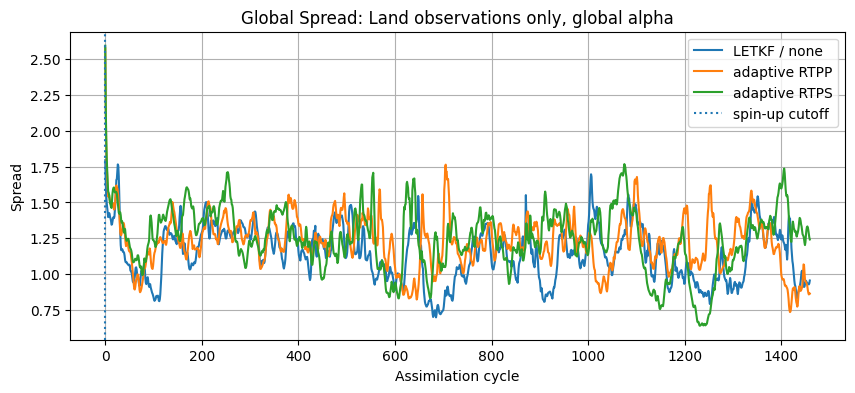

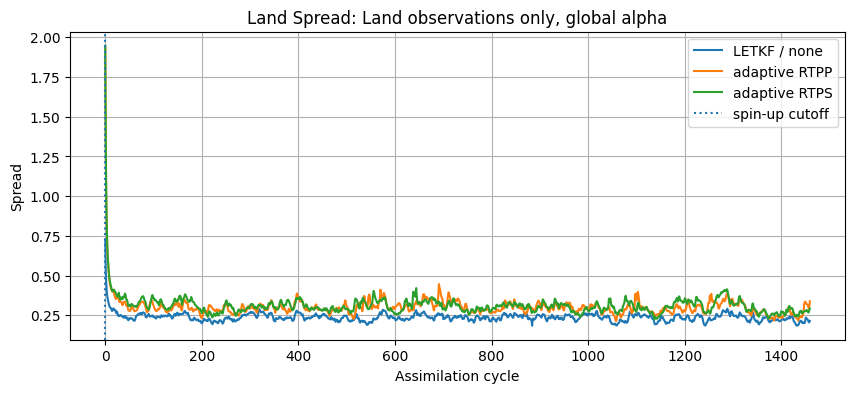

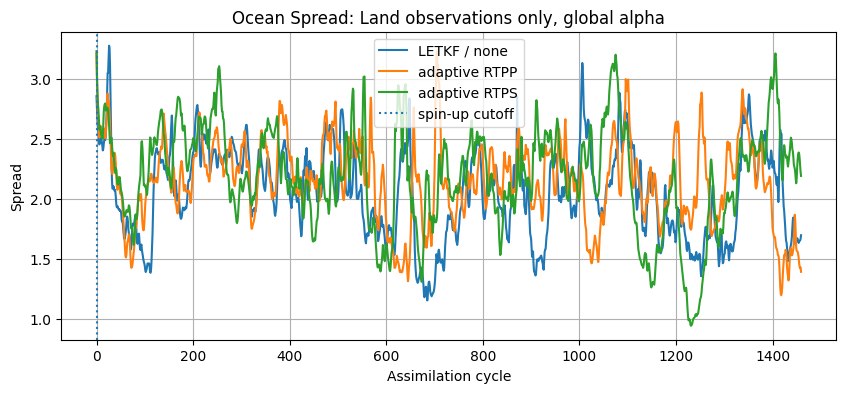

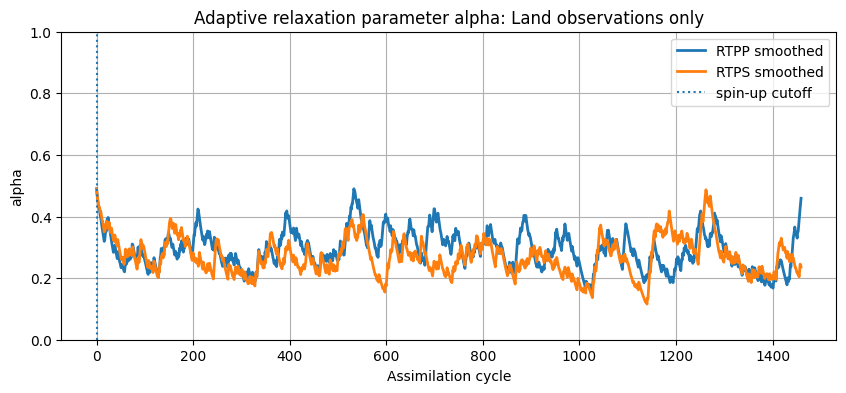

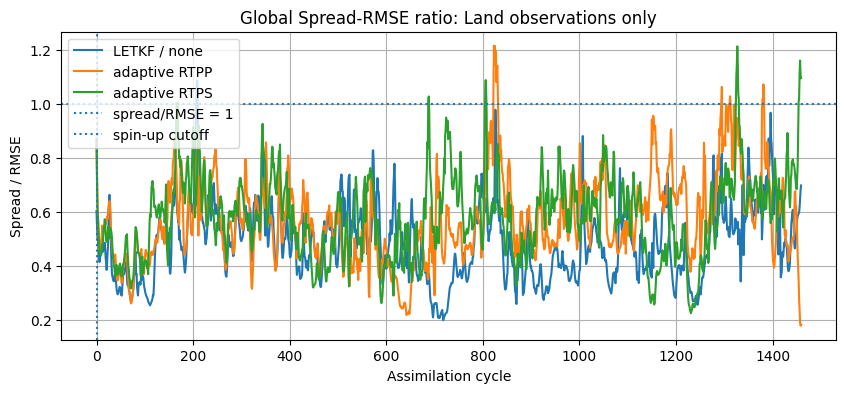

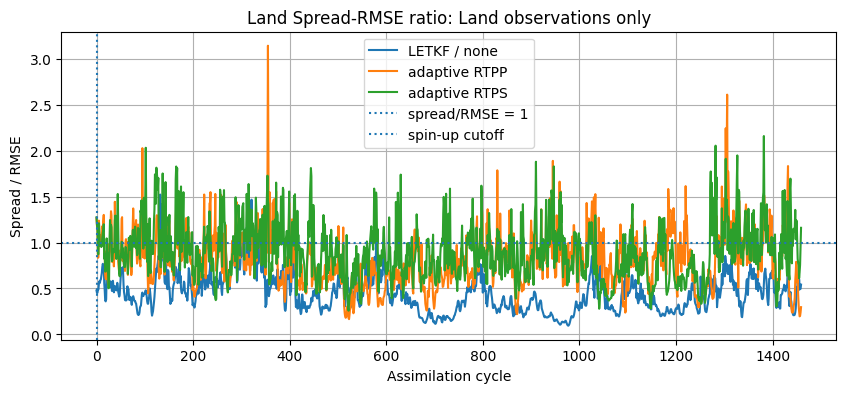

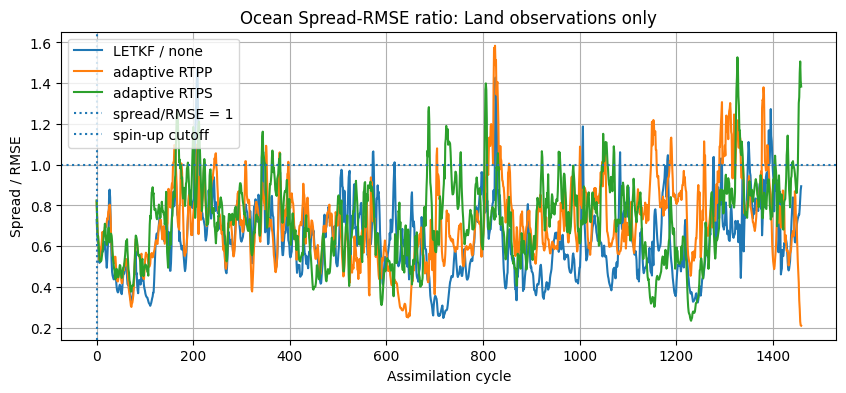

In [6]:
# ------------------------------------------------------------
# 6. Summary table
# ------------------------------------------------------------
try:
    import pandas as pd

    summary_rows = []
    for name, res in results_adaptive_land_ocean.items():
        row = {
            "method": name,
            "mean_rmse_global": np.mean(res["rmse_global"][spinup:]),
            "mean_rmse_land": np.mean(res["rmse_land"][spinup:]),
            "mean_rmse_ocean": np.mean(res["rmse_ocean"][spinup:]),
            "mean_spread_global": np.mean(res["spread_global"][spinup:]),
            "mean_spread_land": np.mean(res["spread_land"][spinup:]),
            "mean_spread_ocean": np.mean(res["spread_ocean"][spinup:]),
        }

        if "alpha_smooth" in res:
            row["mean_alpha_smooth"] = np.mean(res["alpha_smooth"][spinup:])
            row["mean_alpha_diag"] = np.mean(res["alpha_diag"][spinup:])

        summary_rows.append(row)

    summary_adaptive_land_ocean_df = pd.DataFrame(summary_rows)
    display(summary_adaptive_land_ocean_df)

except Exception:
    pass


# ------------------------------------------------------------
# 7. RMSE 時系列: Global / Land / Ocean
# ------------------------------------------------------------
plot_specs = [
    ("rmse_global", "Global RMSE"),
    ("rmse_land", "Land RMSE"),
    ("rmse_ocean", "Ocean RMSE"),
]

for key, title in plot_specs:
    plt.figure(figsize=(10, 4))
    plt.plot(results_adaptive_land_ocean["none"][key], label="LETKF / none")
    plt.plot(results_adaptive_land_ocean["adaptive_rtpp"][key], label="adaptive RTPP")
    plt.plot(results_adaptive_land_ocean["adaptive_rtps"][key], label="adaptive RTPS")
    plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
    plt.xlabel("Assimilation cycle")
    plt.ylabel("RMSE")
    plt.title(f"{title}: Land observations only, global alpha")
    plt.grid(True)
    plt.legend()
    plt.show()


# ------------------------------------------------------------
# 8. Spread 時系列: Global / Land / Ocean
# ------------------------------------------------------------
plot_specs = [
    ("spread_global", "Global Spread"),
    ("spread_land", "Land Spread"),
    ("spread_ocean", "Ocean Spread"),
]

for key, title in plot_specs:
    plt.figure(figsize=(10, 4))
    plt.plot(results_adaptive_land_ocean["none"][key], label="LETKF / none")
    plt.plot(results_adaptive_land_ocean["adaptive_rtpp"][key], label="adaptive RTPP")
    plt.plot(results_adaptive_land_ocean["adaptive_rtps"][key], label="adaptive RTPS")
    plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
    plt.xlabel("Assimilation cycle")
    plt.ylabel("Spread")
    plt.title(f"{title}: Land observations only, global alpha")
    plt.grid(True)
    plt.legend()
    plt.show()


# ------------------------------------------------------------
# 9. alpha 時系列
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    results_adaptive_land_ocean["adaptive_rtpp"]["alpha_smooth"],
    linewidth=2,
    label="RTPP smoothed",
)
plt.plot(
    results_adaptive_land_ocean["adaptive_rtps"]["alpha_smooth"],
    linewidth=2,
    label="RTPS smoothed",
)
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("alpha")
plt.ylim(0.0, 1.0)
plt.title("Adaptive relaxation parameter alpha: Land observations only")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 10. Spread / RMSE 比: Global / Land / Ocean
# ------------------------------------------------------------
ratio_specs = [
    ("global", "Global"),
    ("land", "Land"),
    ("ocean", "Ocean"),
]

for region, title in ratio_specs:
    rmse_key = f"rmse_{region}"
    spread_key = f"spread_{region}"

    plt.figure(figsize=(10, 4))

    for name, label in [
        ("none", "LETKF / none"),
        ("adaptive_rtpp", "adaptive RTPP"),
        ("adaptive_rtps", "adaptive RTPS"),
    ]:
        ratio = (
            results_adaptive_land_ocean[name][spread_key]
            / (results_adaptive_land_ocean[name][rmse_key] + 1.0e-12)
        )
        plt.plot(ratio, label=label)

    plt.axhline(1.0, linestyle=":", label="spread/RMSE = 1")
    plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
    plt.xlabel("Assimilation cycle")
    plt.ylabel("Spread / RMSE")
    plt.title(f"{title} Spread-RMSE ratio: Land observations only")
    plt.grid(True)
    plt.legend()
    plt.show()

Adaptive RTPS: [np.float64(2.2463340237747773), np.float64(1.250150001138214), np.float64(0.3833461860412803), np.float64(0.3112169055691123), np.float64(3.149805608133234), np.float64(2.1890830967073156)]
Adaptive RTPP: [np.float64(2.2781059124382845), np.float64(1.2268645411929746), np.float64(0.42900439339590063), np.float64(0.30258670801779947), np.float64(3.1877475385380323), np.float64(2.1511423743681495)]


,metric,Adaptive RTPS,Adaptive RTPP
0,RMSE\n(Global),2.246334,2.278106
1,SPREAD\n(Global),1.250150,1.226865
2,RMSE\n(Land),0.383346,0.429004
3,SPREAD\n(Land),0.311217,0.302587
4,RMSE\n(Ocean),3.149806,3.187748
5,SPREAD\n(Ocean),2.189083,2.151142


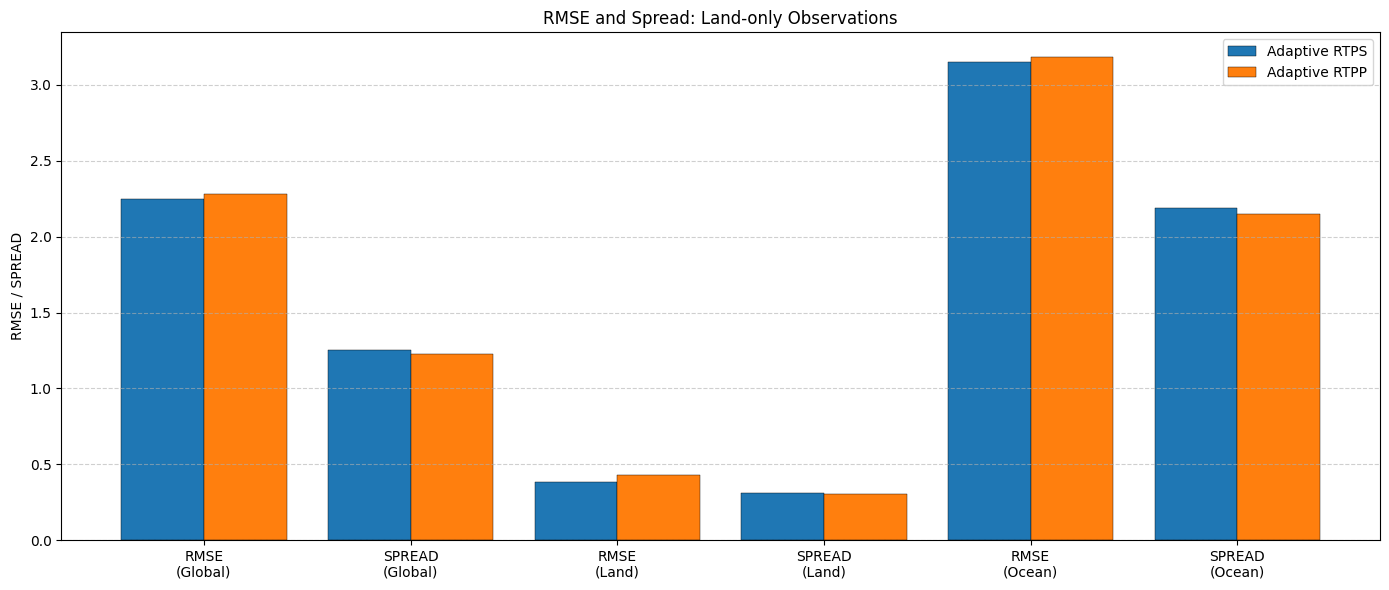

In [7]:
# =====================================================================
# Bar plot: RMSE and Spread for Land-only Observations
# Adaptive RTPS vs Adaptive RTPP
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. 対象結果を取り出す
# ------------------------------------------------------------
res_rtps = results_adaptive_land_ocean["adaptive_rtps"]
res_rtpp = results_adaptive_land_ocean["adaptive_rtpp"]

# spinup が未定義の場合の保険
try:
    spinup
except NameError:
    spinup = 50

# ------------------------------------------------------------
# 2. spinup後平均を計算
# ------------------------------------------------------------
def mean_after_spinup(arr, spinup=50):
    arr = np.asarray(arr)
    return np.mean(arr[spinup:])

rtps_values = [
    mean_after_spinup(res_rtps["rmse_global"], spinup),
    mean_after_spinup(res_rtps["spread_global"], spinup),
    mean_after_spinup(res_rtps["rmse_land"], spinup),
    mean_after_spinup(res_rtps["spread_land"], spinup),
    mean_after_spinup(res_rtps["rmse_ocean"], spinup),
    mean_after_spinup(res_rtps["spread_ocean"], spinup),
]

rtpp_values = [
    mean_after_spinup(res_rtpp["rmse_global"], spinup),
    mean_after_spinup(res_rtpp["spread_global"], spinup),
    mean_after_spinup(res_rtpp["rmse_land"], spinup),
    mean_after_spinup(res_rtpp["spread_land"], spinup),
    mean_after_spinup(res_rtpp["rmse_ocean"], spinup),
    mean_after_spinup(res_rtpp["spread_ocean"], spinup),
]

# ------------------------------------------------------------
# 3. 確認用に数値を表示
# ------------------------------------------------------------
labels = [
    "RMSE\n(Global)",
    "SPREAD\n(Global)",
    "RMSE\n(Land)",
    "SPREAD\n(Land)",
    "RMSE\n(Ocean)",
    "SPREAD\n(Ocean)",
]

print("Adaptive RTPS:", rtps_values)
print("Adaptive RTPP:", rtpp_values)

try:
    import pandas as pd

    bar_summary_df = pd.DataFrame({
        "metric": labels,
        "Adaptive RTPS": rtps_values,
        "Adaptive RTPP": rtpp_values,
    })
    display(bar_summary_df)
except Exception:
    pass

# ------------------------------------------------------------
# 4. 棒グラフを描画
# ------------------------------------------------------------
x = np.arange(len(labels))
width = 0.40

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    rtps_values,
    width,
    label="Adaptive RTPS",
    edgecolor="black",
    linewidth=0.3,
)

plt.bar(
    x + width / 2,
    rtpp_values,
    width,
    label="Adaptive RTPP",
    edgecolor="black",
    linewidth=0.3,
)

plt.xticks(x, labels)
plt.ylabel("RMSE / SPREAD")
plt.title("RMSE and Spread: Land-only Observations")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

\begin{aligned}
\Phi_1 &= \frac{1}{m-1} \text{tr} \left[ H X^b (H X^b)^T \circ R^{-1} \right] \\
\Phi_2 &= \frac{1}{m-1} \text{tr} \left[ H X_{\text{tmp}}^a (H X^b)^T \circ R^{-1} \right] \\
\Phi_3 &= \frac{1}{m-1} \text{tr} \left[ H X_{\text{tmp}}^a (H X_{\text{tmp}}^a)^T \circ R^{-1} \right] \\
\Phi_4 &= \text{tr} \left[ d^{a-b} (d^{o-a})^T \circ R^{-1} \right]
\end{aligned}

\begin{aligned}
\lambda_1 &= \Phi_1 - 2\Phi_2 + \Phi_3 \\
\lambda_2 &= 2\Phi_2 - 2\Phi_3 \\
\lambda_3 &= \Phi_3 - \Phi_4 \\
\end{aligned}

\begin{aligned}
\alpha^{smooth}_{RTPP,RTPS} (t) = \tau \cdot \alpha_{RTPP,RTPS} (t) + (1 - \tau) \cdot \alpha^{smooth}_{RTPP,RTPS} (t - 1)
\end{aligned}

Static RTPS alpha = 0.1
Static RTPP alpha = 0.1
Running static RTPS ...
Running static RTPP ...
Static experiments finished.


,method,RMSE (Global),SPREAD (Global),RMSE (Land),SPREAD (Land),RMSE (Ocean),SPREAD (Ocean)
0,Adaptive RTPS,2.246334,1.250150,0.383346,0.311217,3.149806,2.189083
1,Adaptive RTPP,2.278106,1.226865,0.429004,0.302587,3.187748,2.151142
2,Static RTPS α=0.10,2.587105,1.161760,0.677884,0.259926,3.564054,2.063593
3,Static RTPP α=0.10,2.593657,1.147566,0.636693,0.254722,3.594642,2.040410


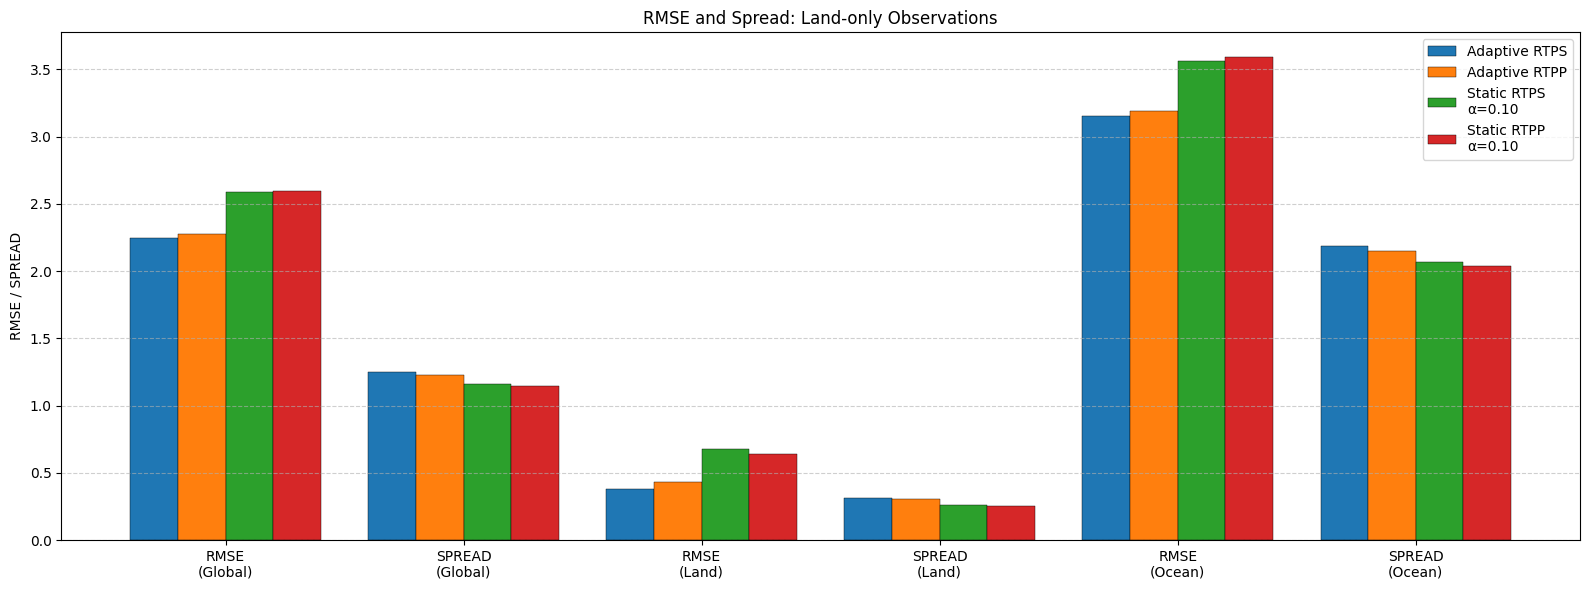

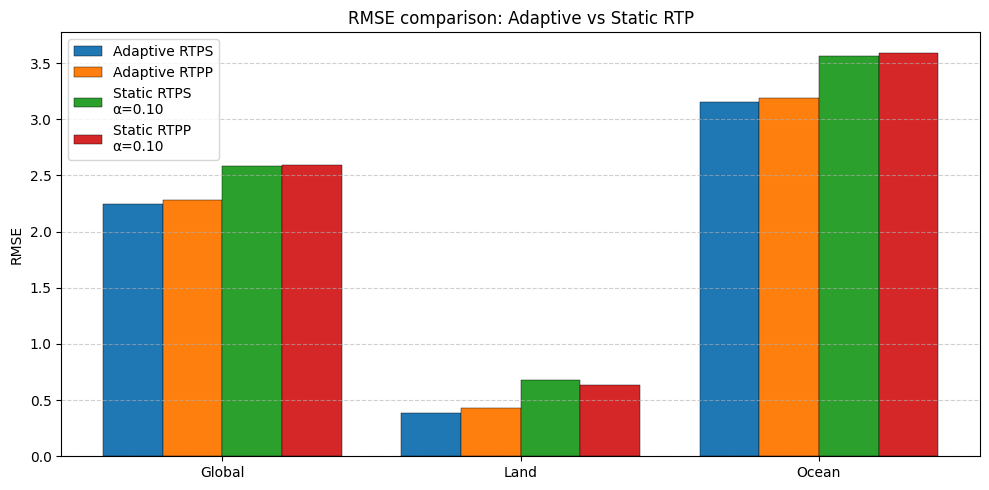

,method,Global Spread/RMSE,Land Spread/RMSE,Ocean Spread/RMSE
0,Adaptive RTPS,0.556529,0.811843,0.694990
1,Adaptive RTPP,0.538546,0.705323,0.674816
2,Static RTPS α=0.10,0.449058,0.383438,0.579002
3,Static RTPP α=0.10,0.442451,0.400070,0.567625


In [8]:
# =====================================================================
# Adaptive RTPP/RTPS vs Static RTPP/RTPS
# static alpha を毎回反映する版
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. 手動で static alpha を指定
# ------------------------------------------------------------
# ここを好きな値に変える
static_alpha_rtps = 0.1
static_alpha_rtpp = 0.1

print(f"Static RTPS alpha = {static_alpha_rtps}")
print(f"Static RTPP alpha = {static_alpha_rtpp}")

# ------------------------------------------------------------
# 1. static RTPS / static RTPP を毎回上書き実行
# ------------------------------------------------------------
print("Running static RTPS ...")
results_adaptive_land_ocean["static_rtps"] = run_letkf_experiment_regional(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices_land_ocean,
    sigma=sigma,
    inflation=inflation,
    method="rtps",
    alpha=static_alpha_rtps,
    seed=seed,
)

print("Running static RTPP ...")
results_adaptive_land_ocean["static_rtpp"] = run_letkf_experiment_regional(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices_land_ocean,
    sigma=sigma,
    inflation=inflation,
    method="rtpp",
    alpha=static_alpha_rtpp,
    seed=seed,
)

print("Static experiments finished.")

# ------------------------------------------------------------
# 2. spinup 後平均を計算する関数
# ------------------------------------------------------------
def mean_after_spinup(arr, spinup):
    arr = np.asarray(arr)
    return float(np.mean(arr[spinup:]))

# ------------------------------------------------------------
# 3. 棒グラフ用の値を作る
# ------------------------------------------------------------
metric_keys = [
    "rmse_global",
    "spread_global",
    "rmse_land",
    "spread_land",
    "rmse_ocean",
    "spread_ocean",
]

x_labels = [
    "RMSE\n(Global)",
    "SPREAD\n(Global)",
    "RMSE\n(Land)",
    "SPREAD\n(Land)",
    "RMSE\n(Ocean)",
    "SPREAD\n(Ocean)",
]

method_specs = [
    ("adaptive_rtps", "Adaptive RTPS"),
    ("adaptive_rtpp", "Adaptive RTPP"),
    ("static_rtps", f"Static RTPS\nα={static_alpha_rtps:.2f}"),
    ("static_rtpp", f"Static RTPP\nα={static_alpha_rtpp:.2f}"),
]

bar_values = {}

for method_key, method_label in method_specs:
    res = results_adaptive_land_ocean[method_key]
    bar_values[method_key] = [
        mean_after_spinup(res[key], spinup)
        for key in metric_keys
    ]

# ------------------------------------------------------------
# 4. 確認用テーブル
# ------------------------------------------------------------
try:
    import pandas as pd

    rows = []
    for method_key, method_label in method_specs:
        row = {"method": method_label.replace("\n", " ")}
        for label, value in zip(x_labels, bar_values[method_key]):
            row[label.replace("\n", " ")] = value
        rows.append(row)

    compare_static_df = pd.DataFrame(rows)
    display(compare_static_df)

except Exception:
    for method_key, method_label in method_specs:
        print(method_label, bar_values[method_key])

# ------------------------------------------------------------
# 5. RMSE / Spread 棒グラフ
# ------------------------------------------------------------
x = np.arange(len(x_labels))
width = 0.20

plt.figure(figsize=(16, 6))

for j, (method_key, method_label) in enumerate(method_specs):
    offset = (j - 1.5) * width
    plt.bar(
        x + offset,
        bar_values[method_key],
        width,
        label=method_label,
        edgecolor="black",
        linewidth=0.3,
    )

plt.xticks(x, x_labels)
plt.ylabel("RMSE / SPREAD")
plt.title("RMSE and Spread: Land-only Observations")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. RMSEだけの比較
# ------------------------------------------------------------
rmse_metric_keys = [
    "rmse_global",
    "rmse_land",
    "rmse_ocean",
]

rmse_x_labels = [
    "Global",
    "Land",
    "Ocean",
]

rmse_bar_values = {}

for method_key, method_label in method_specs:
    res = results_adaptive_land_ocean[method_key]
    rmse_bar_values[method_key] = [
        mean_after_spinup(res[key], spinup)
        for key in rmse_metric_keys
    ]

x = np.arange(len(rmse_x_labels))
width = 0.20

plt.figure(figsize=(10, 5))

for j, (method_key, method_label) in enumerate(method_specs):
    offset = (j - 1.5) * width
    plt.bar(
        x + offset,
        rmse_bar_values[method_key],
        width,
        label=method_label,
        edgecolor="black",
        linewidth=0.3,
    )

plt.xticks(x, rmse_x_labels)
plt.ylabel("RMSE")
plt.title("RMSE comparison: Adaptive vs Static RTP")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Spread/RMSE 比
# ------------------------------------------------------------
ratio_rows = []

for method_key, method_label in method_specs:
    res = results_adaptive_land_ocean[method_key]

    mean_rmse_global = mean_after_spinup(res["rmse_global"], spinup)
    mean_spread_global = mean_after_spinup(res["spread_global"], spinup)

    mean_rmse_land = mean_after_spinup(res["rmse_land"], spinup)
    mean_spread_land = mean_after_spinup(res["spread_land"], spinup)

    mean_rmse_ocean = mean_after_spinup(res["rmse_ocean"], spinup)
    mean_spread_ocean = mean_after_spinup(res["spread_ocean"], spinup)

    ratio_rows.append({
        "method": method_label.replace("\n", " "),
        "Global Spread/RMSE": mean_spread_global / (mean_rmse_global + 1.0e-12),
        "Land Spread/RMSE": mean_spread_land / (mean_rmse_land + 1.0e-12),
        "Ocean Spread/RMSE": mean_spread_ocean / (mean_rmse_ocean + 1.0e-12),
    })

try:
    import pandas as pd
    ratio_df = pd.DataFrame(ratio_rows)
    display(ratio_df)
except Exception:
    for row in ratio_rows:
        print(row)

Static RTPS alpha = 0.27
Static RTPP alpha = 0.29
Running static RTPS ...
Running static RTPP ...
Static experiments finished.


,Region,Adaptive RTPS,Static RTPS alpha=0.27,Adaptive RTPP,Static RTPP alpha=0.29
0,Global,2.246334,2.343906,2.278106,2.333957
1,Land,0.383346,0.413682,0.429004,0.475479
2,Ocean,3.149806,3.283595,3.187748,3.257732


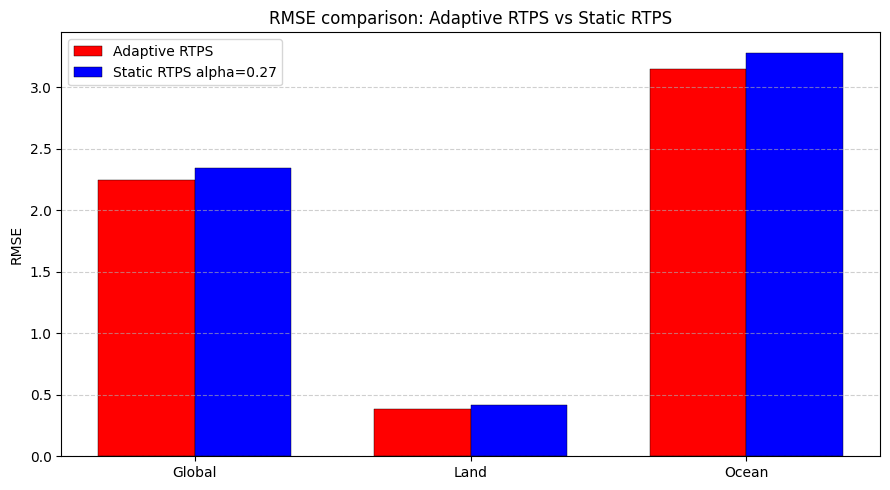

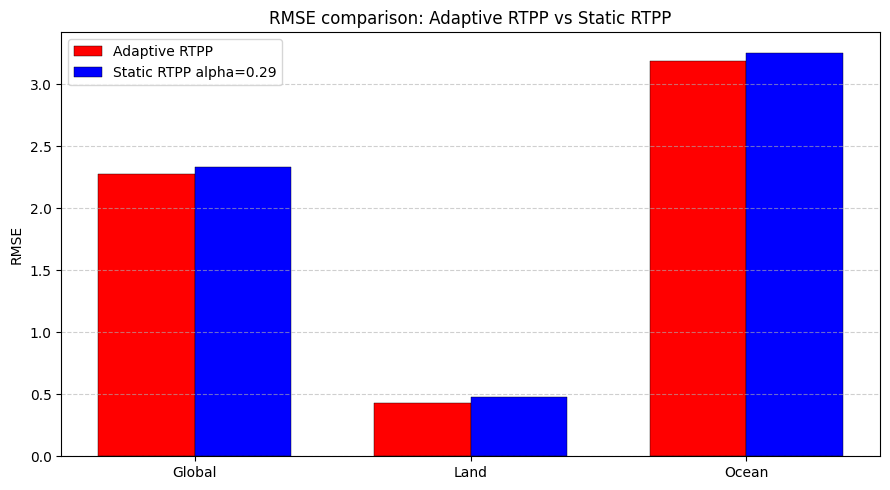


===== RMSE summary after spinup =====
RTPS Global: Adaptive=2.246334, Static=2.343906, better=Adaptive RTPS
RTPS Land: Adaptive=0.383346, Static=0.413682, better=Adaptive RTPS
RTPS Ocean: Adaptive=3.149806, Static=3.283595, better=Adaptive RTPS

RTPP Global: Adaptive=2.278106, Static=2.333957, better=Adaptive RTPP
RTPP Land: Adaptive=0.429004, Static=0.475479, better=Adaptive RTPP
RTPP Ocean: Adaptive=3.187748, Static=3.257732, better=Adaptive RTPP


In [12]:
# =====================================================================
# RMSE only:
# Adaptive RTPS vs Static RTPS
# Adaptive RTPP vs Static RTPP
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. static alpha を手動指定
# ------------------------------------------------------------
# ここを変えれば、必ずその alpha で static 実験を再実行します
static_alpha_rtps = 0.27
static_alpha_rtpp = 0.29

print(f"Static RTPS alpha = {static_alpha_rtps}")
print(f"Static RTPP alpha = {static_alpha_rtpp}")

# ------------------------------------------------------------
# 1. static RTPS / static RTPP を毎回上書き実行
# ------------------------------------------------------------
print("Running static RTPS ...")
results_adaptive_land_ocean["static_rtps"] = run_letkf_experiment_regional(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices_land_ocean,
    sigma=sigma,
    inflation=inflation,
    method="rtps",
    alpha=static_alpha_rtps,
    seed=seed,
)

print("Running static RTPP ...")
results_adaptive_land_ocean["static_rtpp"] = run_letkf_experiment_regional(
    y_o_data=y_o_data_full[:num_eval_cycles],
    true_states=true_states[:num_eval_cycles],
    obs_indices=obs_indices_land_ocean,
    sigma=sigma,
    inflation=inflation,
    method="rtpp",
    alpha=static_alpha_rtpp,
    seed=seed,
)

print("Static experiments finished.")

# ------------------------------------------------------------
# 2. spinup 後平均を計算する関数
# ------------------------------------------------------------
def mean_after_spinup(arr, spinup):
    arr = np.asarray(arr)
    return float(np.mean(arr[spinup:]))

# ------------------------------------------------------------
# 3. RMSEだけ取り出す
# ------------------------------------------------------------
rmse_keys = [
    "rmse_global",
    "rmse_land",
    "rmse_ocean",
]

x_labels = [
    "Global",
    "Land",
    "Ocean",
]

# RTPS比較
rtps_adaptive_values = [
    mean_after_spinup(results_adaptive_land_ocean["adaptive_rtps"][key], spinup)
    for key in rmse_keys
]

rtps_static_values = [
    mean_after_spinup(results_adaptive_land_ocean["static_rtps"][key], spinup)
    for key in rmse_keys
]

# RTPP比較
rtpp_adaptive_values = [
    mean_after_spinup(results_adaptive_land_ocean["adaptive_rtpp"][key], spinup)
    for key in rmse_keys
]

rtpp_static_values = [
    mean_after_spinup(results_adaptive_land_ocean["static_rtpp"][key], spinup)
    for key in rmse_keys
]

# ------------------------------------------------------------
# 4. 数値テーブル表示
# ------------------------------------------------------------
try:
    import pandas as pd

    rmse_compare_df = pd.DataFrame({
        "Region": x_labels,
        "Adaptive RTPS": rtps_adaptive_values,
        f"Static RTPS alpha={static_alpha_rtps:.2f}": rtps_static_values,
        "Adaptive RTPP": rtpp_adaptive_values,
        f"Static RTPP alpha={static_alpha_rtpp:.2f}": rtpp_static_values,
    })

    display(rmse_compare_df)

except Exception:
    print("RTPS adaptive:", rtps_adaptive_values)
    print("RTPS static  :", rtps_static_values)
    print("RTPP adaptive:", rtpp_adaptive_values)
    print("RTPP static  :", rtpp_static_values)

# ------------------------------------------------------------
# 5. RTPS: Adaptive vs Static
# ------------------------------------------------------------
x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    rtps_adaptive_values,
    width,
    label="Adaptive RTPS",
    edgecolor="black",
    linewidth=0.3,
    color="red"
)

plt.bar(
    x + width / 2,
    rtps_static_values,
    width,
    label=f"Static RTPS alpha={static_alpha_rtps:.2f}",
    edgecolor="black",
    linewidth=0.3,
    color="blue"
)

plt.xticks(x, x_labels)
plt.ylabel("RMSE")
plt.title("RMSE comparison: Adaptive RTPS vs Static RTPS")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. RTPP: Adaptive vs Static
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    rtpp_adaptive_values,
    width,
    label="Adaptive RTPP",
    edgecolor="black",
    linewidth=0.3,
    color="red"
)

plt.bar(
    x + width / 2,
    rtpp_static_values,
    width,
    label=f"Static RTPP alpha={static_alpha_rtpp:.2f}",
    edgecolor="black",
    linewidth=0.3,
    color="blue"
)

plt.xticks(x, x_labels)
plt.ylabel("RMSE")
plt.title("RMSE comparison: Adaptive RTPP vs Static RTPP")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. どちらが良いか簡易表示
# ------------------------------------------------------------
print()
print("===== RMSE summary after spinup =====")

for region, a_val, s_val in zip(x_labels, rtps_adaptive_values, rtps_static_values):
    better = "Adaptive RTPS" if a_val < s_val else "Static RTPS"
    print(
        f"RTPS {region}: "
        f"Adaptive={a_val:.6f}, Static={s_val:.6f}, better={better}"
    )

print()

for region, a_val, s_val in zip(x_labels, rtpp_adaptive_values, rtpp_static_values):
    better = "Adaptive RTPP" if a_val < s_val else "Static RTPP"
    print(
        f"RTPP {region}: "
        f"Adaptive={a_val:.6f}, Static={s_val:.6f}, better={better}"
    )